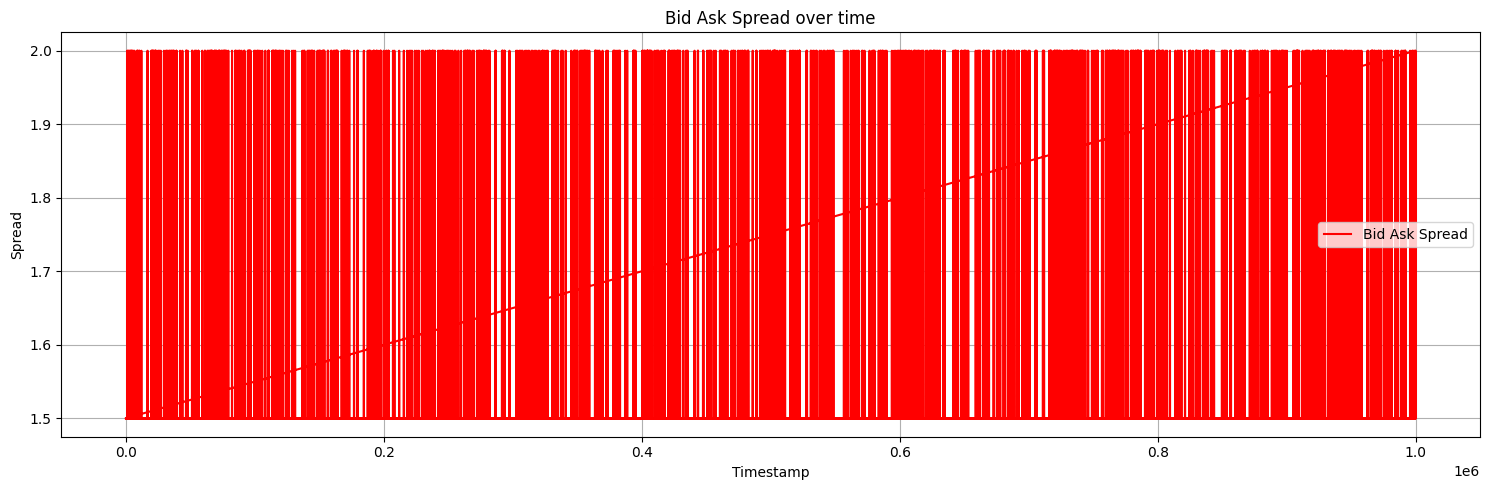

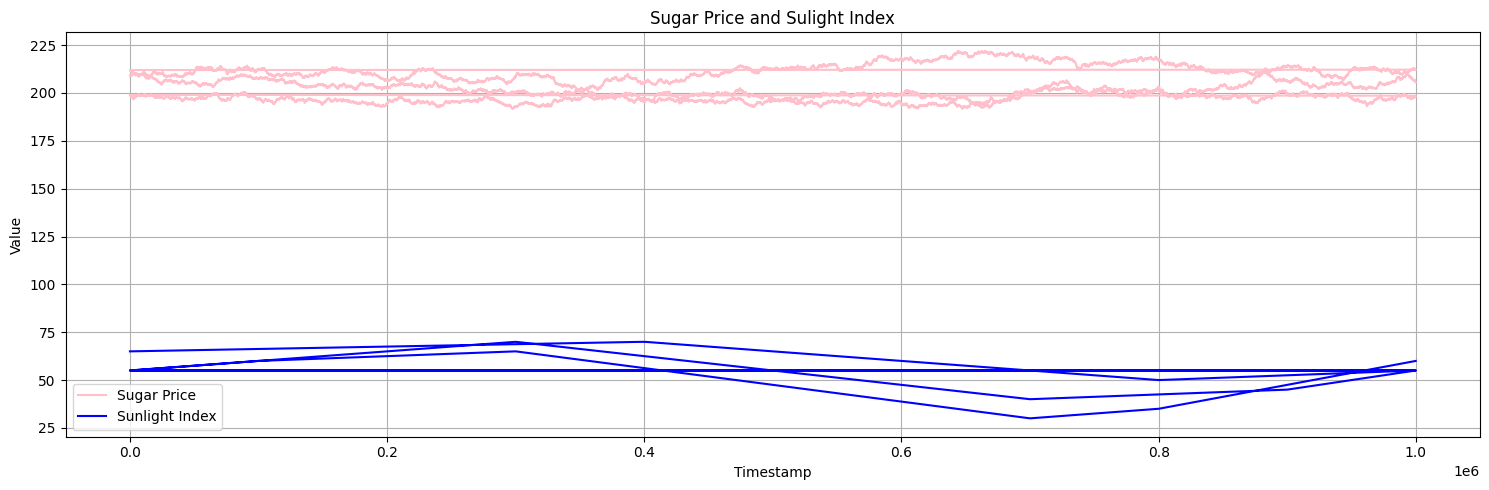

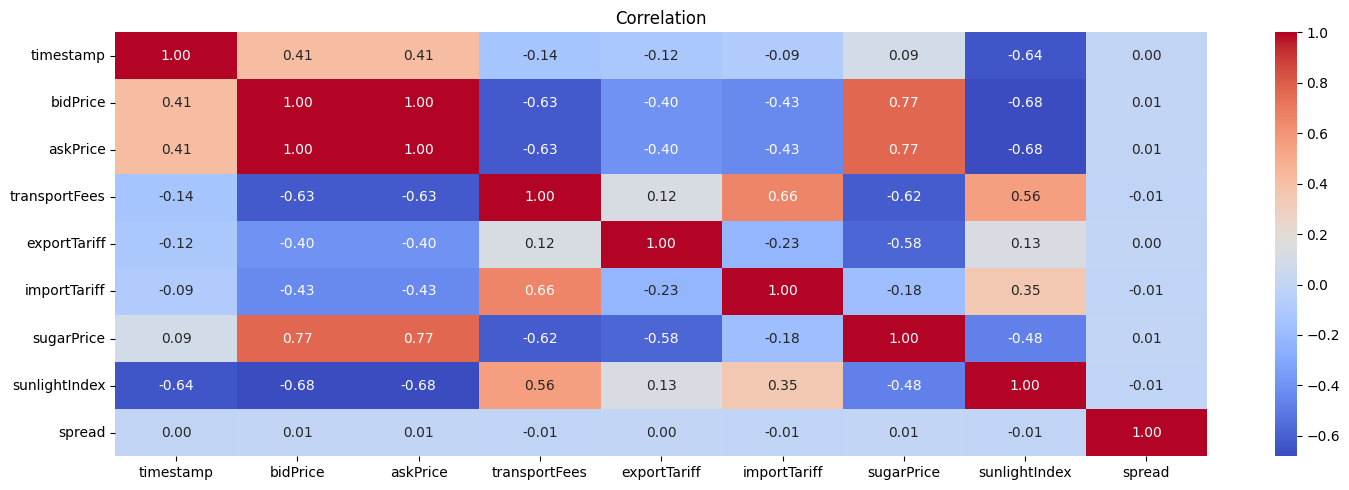

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

#file extrated
extract_path = r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle"
obs_paths = [
    r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle\observations_round_5_day_2.csv",
    r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle\observations_round_5_day_3.csv",
    r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle\observations_round_5_day_4.csv"
]

#merged all 3 days of obs data
df = pd.concat([pd.read_csv(path) for path in obs_paths], ignore_index=True)

df["spread"] = df["askPrice"] - df["bidPrice"]

#bid ask plot
plt.figure(figsize = (15,5))
plt.plot(df['timestamp'], df['spread'], label = 'Bid Ask Spread', color = 'red')
plt.title("Bid Ask Spread over time")
plt.xlabel("Timestamp")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#sugarprice and sunlight index
plt.figure(figsize= (15, 5))
plt.plot(df['timestamp'], df['sugarPrice'], label = 'Sugar Price', color= 'pink')
plt.plot(df['timestamp'], df['sunlightIndex'], label = 'Sunlight Index', color = 'blue')
plt.title("Sugar Price and Sulight Index")
plt.xlabel("Timestamp")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#correlation
plt.figure(figsize= (15, 5))
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm" , fmt = '.02f')
plt.title("Correlation")
plt.tight_layout()
plt.show()

                  profit_and_loss    spread  volume_imbalance  mid_price
profit_and_loss               NaN       NaN               NaN        NaN
spread                        NaN  1.000000          0.079413   0.453308
volume_imbalance              NaN  0.079413          1.000000  -0.034526
mid_price                     NaN  0.453308         -0.034526   1.000000


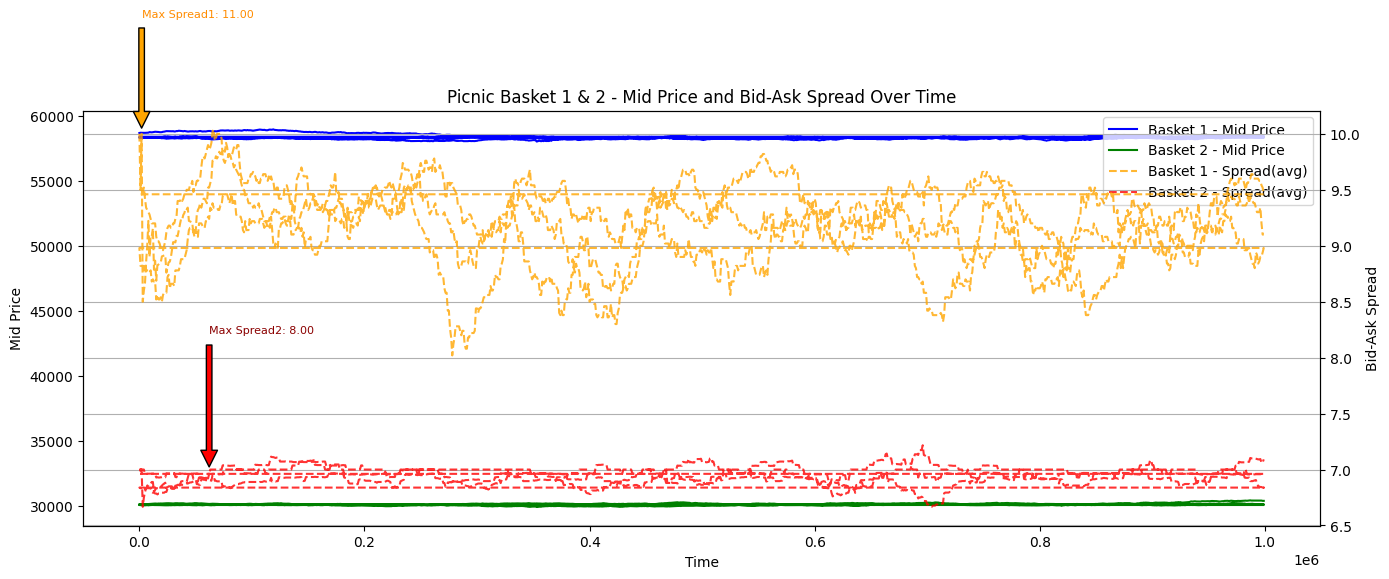

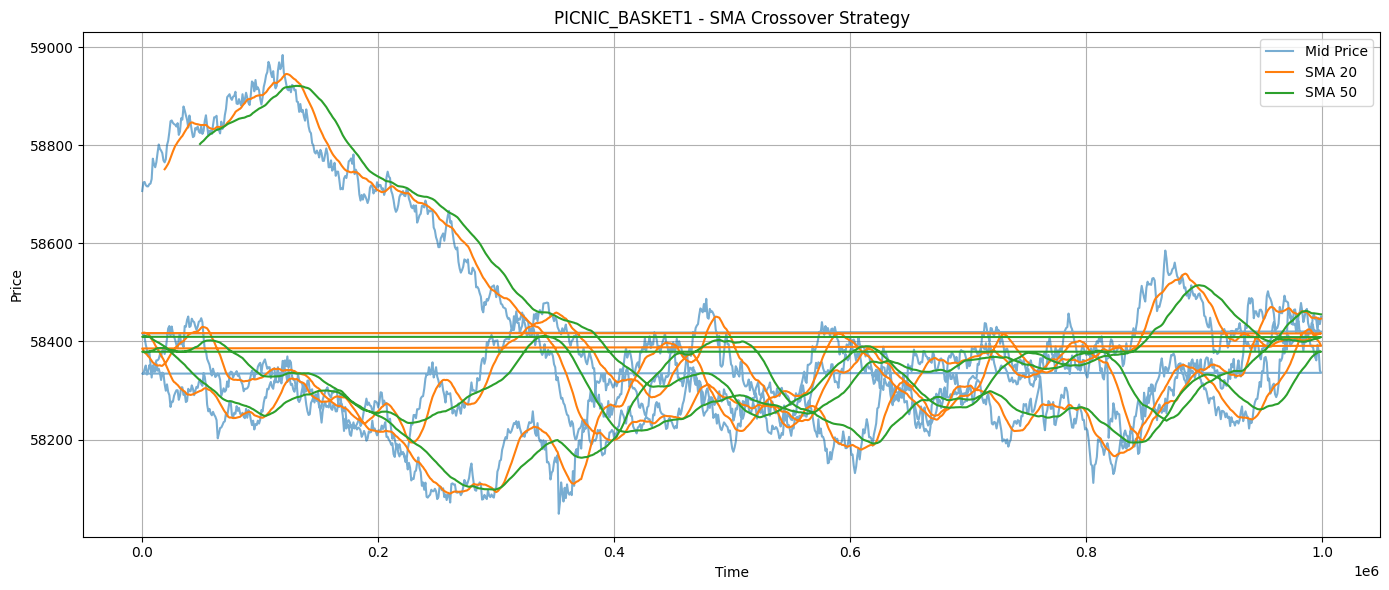

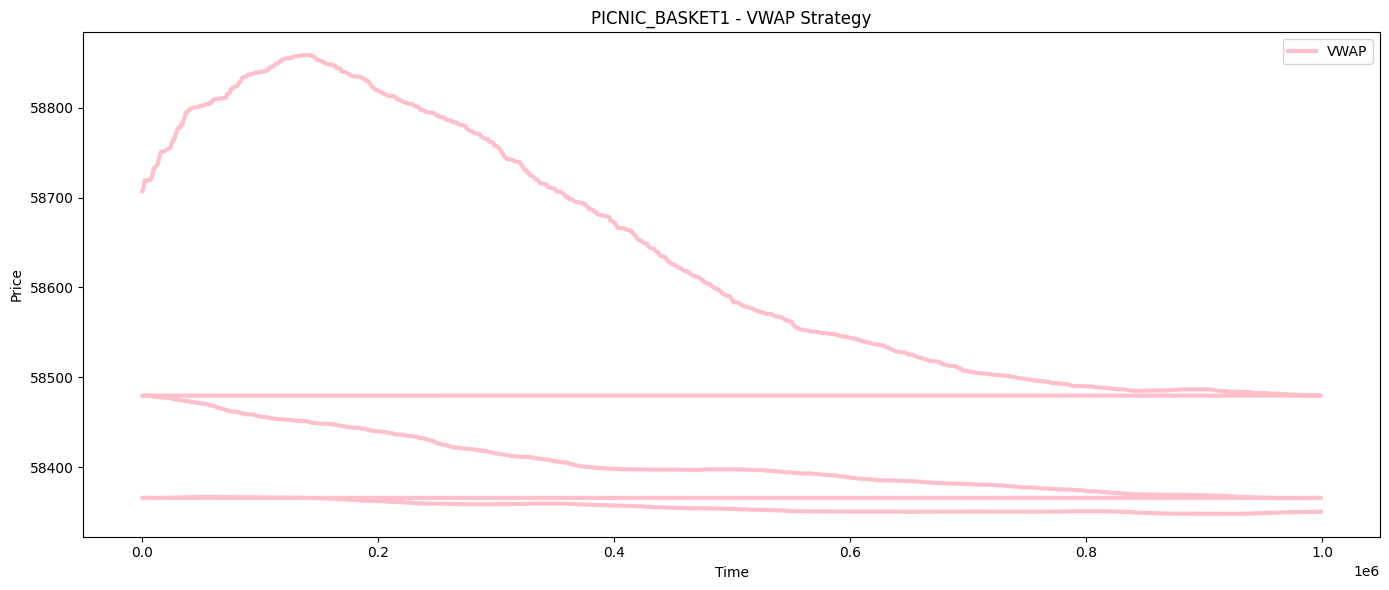

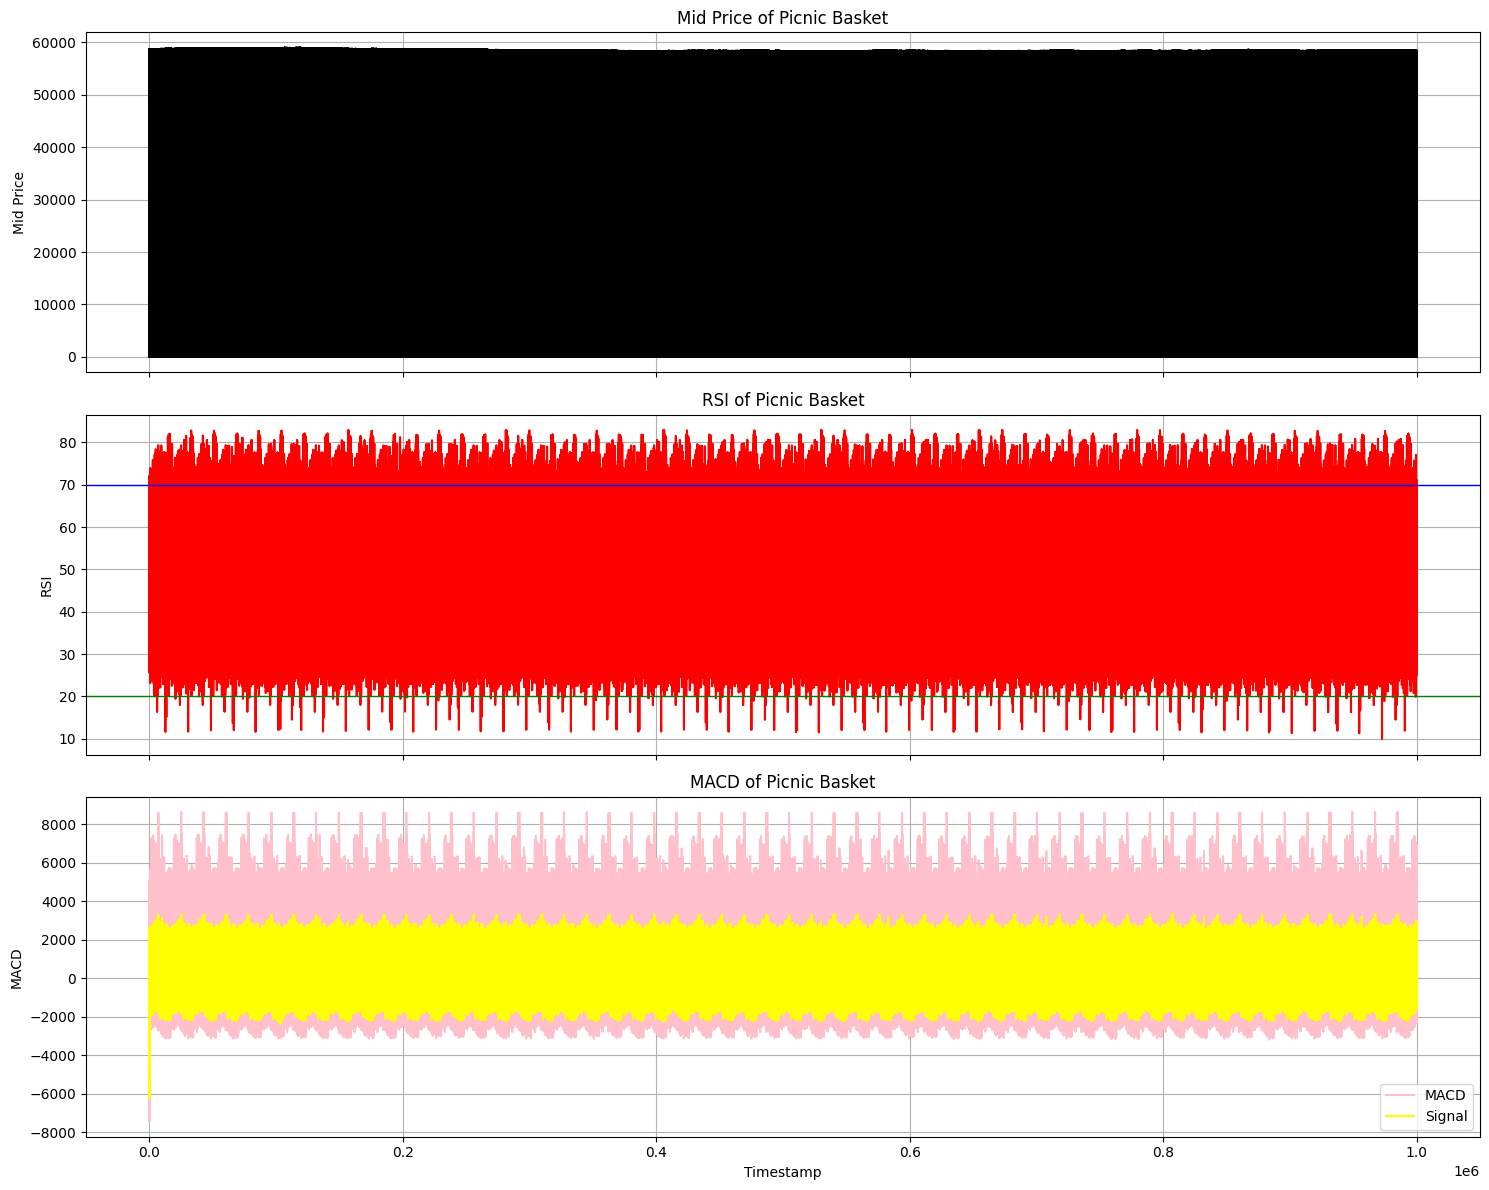

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

#file extrated
extract_path = r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle"
price_paths = [
    r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle\prices_round_5_day_2.csv",
    r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle\prices_round_5_day_3.csv",
    r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle\prices_round_5_day_4.csv"
]

#merged all 3 days of price data
df = pd.concat([pd.read_csv(path, delimiter=';') for path in price_paths], ignore_index=True)


#bid ask spread
df['bid_ask_spread1'] = df['ask_price_1'] - df['bid_price_1']
df['bid_ask_spread2'] = df['ask_price_2'] - df['bid_price_2']

df['mid_price'] = pd.to_numeric(df['mid_price'], errors='coerce')
df['bid_volume_1'] = pd.to_numeric(df['bid_volume_1'], errors='coerce')
df['ask_volume_1'] = pd.to_numeric(df['ask_volume_1'], errors='coerce')

df_pb1 = df[df['product'] == 'PICNIC_BASKET1']
df_pb2 = df[df['product'] == 'PICNIC_BASKET2']


df_pb1_sampled = df_pb1.iloc[::10].copy()
df_pb2_sampled = df_pb2.iloc[::10].copy()

df_pb1_sampled['spread_avg'] = df_pb1_sampled['bid_ask_spread1'].rolling(window=50, min_periods=1).mean()
df_pb2_sampled['spread_avg'] = df_pb2_sampled['bid_ask_spread2'].rolling(window=50, min_periods=1).mean()

max1_idx = df_pb1_sampled['bid_ask_spread1'].idxmax()
max2_idx = df_pb2_sampled['bid_ask_spread2'].idxmax()

# Plot with secondary y-axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Mid Prices (left y-axis)
ax1.plot(df_pb1_sampled['timestamp'], df_pb1_sampled['mid_price'], label='Basket 1 - Mid Price', color='blue',)
ax1.plot(df_pb2_sampled['timestamp'], df_pb2_sampled['mid_price'], label='Basket 2 - Mid Price', color='green')
ax1.set_ylabel("Mid Price")
ax1.set_xlabel("Time")

# Bid-Ask Spreads (right y-axis)
ax2 = ax1.twinx()
ax2.plot(df_pb1_sampled['timestamp'], df_pb1_sampled['spread_avg'], label='Basket 1 - Spread(avg)', color='orange', linestyle='--', alpha = 0.8)
ax2.plot(df_pb2_sampled['timestamp'], df_pb2_sampled['spread_avg'], label='Basket 2 - Spread(avg)', color='red', linestyle='--', alpha = 0.8)
ax2.set_ylabel("Bid-Ask Spread")


# Annotations
ax2.annotate(f'Max Spread1: {df_pb1_sampled.loc[max1_idx, "bid_ask_spread1"]:.2f}',
             xy=(df_pb1_sampled.loc[max1_idx, 'timestamp'], df_pb1_sampled.loc[max1_idx, 'spread_avg']),
             xytext=(df_pb1_sampled.loc[max1_idx, 'timestamp'], df_pb1_sampled['spread_avg'].max() + 1),
             arrowprops=dict(facecolor='orange', shrink=0.05),
             fontsize=8, color='darkorange')

ax2.annotate(f'Max Spread2: {df_pb2_sampled.loc[max2_idx, "bid_ask_spread2"]:.2f}',
             xy=(df_pb2_sampled.loc[max2_idx, 'timestamp'], df_pb2_sampled.loc[max2_idx, 'spread_avg']),
             xytext=(df_pb2_sampled.loc[max2_idx, 'timestamp'], df_pb2_sampled['spread_avg'].max() + 1),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=8, color='darkred')

#correlation
df["spread"] = df["ask_price_1"] - df["bid_price_1"]
df["volume_imbalance"] = (df["bid_volume_1"] - df["ask_volume_1"]) / \
                         (df["bid_volume_1"] + df["ask_volume_1"] + 1e-5)  
print(df[["profit_and_loss", "spread","volume_imbalance", "mid_price"]].corr())




# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title("Picnic Basket 1 & 2 - Mid Price and Bid-Ask Spread Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()


#simple moving average
df_pb1 = df[df['product'] == 'PICNIC_BASKET1'].copy()
df_pb1['mid_price'] = pd.to_numeric(df_pb1['mid_price'], errors='coerce')
df_pb1 = df_pb1.dropna(subset=['mid_price'])  # Drop rows with NaN mid price

# Sample and calculate SMAs
df_pb1 = df_pb1.iloc[::10]
df_pb1['sma_20'] = df_pb1['mid_price'].rolling(window=20).mean()
df_pb1['sma_50'] = df_pb1['mid_price'].rolling(window=50).mean()

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_pb1['timestamp'], df_pb1['mid_price'], label='Mid Price', alpha=0.6)
plt.plot(df_pb1['timestamp'], df_pb1['sma_20'], label='SMA 20')
plt.plot(df_pb1['timestamp'], df_pb1['sma_50'], label='SMA 50')
plt.title("PICNIC_BASKET1 - SMA Crossover Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#vwap strategy
df_pb1.loc[:, 'vwap_numerator'] = df_pb1['mid_price'] * (df_pb1['ask_volume_1']+ df_pb1['bid_volume_1'])
df_pb1.loc[:, 'vwap_denominator'] = df_pb1['ask_volume_1'] + df_pb1['bid_volume_1']
df_pb1.loc[:, 'vwap'] = df_pb1['vwap_numerator'].cumsum() / df_pb1['vwap_denominator'].cumsum()


#plot
plt.figure(figsize=(14, 6))
plt.plot(df_pb1['timestamp'], df_pb1['vwap'], label='VWAP', color = 'pink', linewidth = 3)
plt.title("PICNIC_BASKET1 - VWAP Strategy")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

#rsi
window_length =  14
delta = df["mid_price"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window = window_length).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window = window_length).mean()
rsi = gain / loss
df["RSI"] = 100 - (100 / (1 + rsi))

fig, axes = plt.subplots(3, 1, figsize = (15, 12), sharex = True)

#midprice
axes[0].plot(df["timestamp"], df["mid_price"], label="Mid Price", color="black")
axes[0].set_title("Mid Price of Picnic Basket")
axes[0].set_ylabel("Mid Price")
axes[0].grid(True)

#rsi plot
axes[1].plot(df["timestamp"], df["RSI"], label = "RSI", color = "red")
axes[1].axhline(70, color = 'blue', linestyle = 'solid', linewidth = 1)
axes[1].axhline(20, color = 'green', linestyle = 'solid', linewidth = 1)
axes[1].set_title("RSI of Picnic Basket")
axes[1].set_ylabel("RSI")
axes[1].grid(True)

#macd
exp1 = df["mid_price"].ewm(span = 12, adjust = False).mean()
exp2 = df["mid_price"].ewm(span = 26, adjust = False).mean()
df["MacD"] = exp1 - exp2
df["Signal"] = df["MacD"].ewm(span = 10, adjust = False).mean()

axes[2].plot(df["timestamp"], df["MacD"], label = "MACD", color = "pink")
axes[2].plot(df["timestamp"], df["Signal"], label = "Signal", color = "yellow")
axes[2].set_title("MACD of Picnic Basket")
axes[2].set_ylabel("MACD")
axes[2].grid(True)
axes[2].legend()
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()


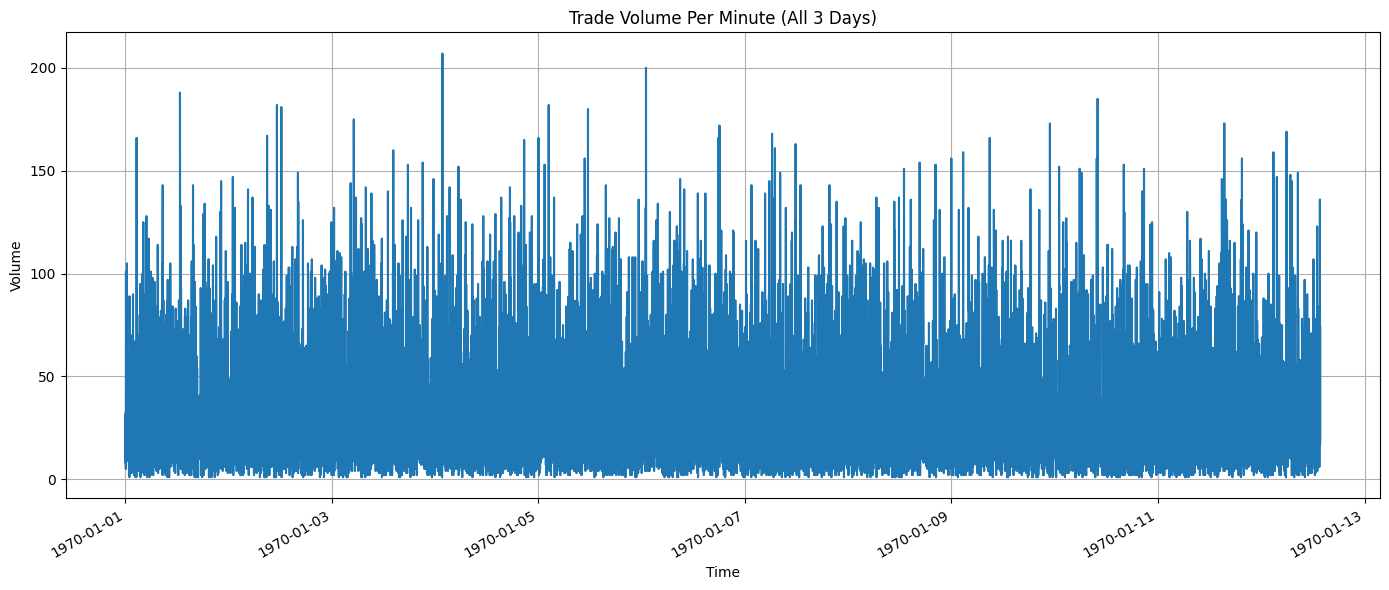

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

#file extrated
extract_path = r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle"
trades_file = [
    r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle\trades_round_5_day_2.csv",
    r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle\trades_round_5_day_3.csv",
    r"C:\Users\AHILI\Downloads\round-5-island-data-bottle\round-5-island-data-bottle\trades_round_5_day_4.csv"
]

#merging all 3 files
trades = pd.concat([pd.read_csv(file, delimiter=';') for file in trades_file], ignore_index=True)

#Convert timestamp to datetime
trades['timestamp'] = pd.to_datetime(trades['timestamp'], unit='s')

#Round to the nearest minute for grouping
trades['minute'] = trades['timestamp'].dt.floor('1min')

#trade vol per min
volume_per_minute = trades.groupby('minute')['quantity'].sum()

#Plot the result
plt.figure(figsize=(14, 6))
volume_per_minute.plot()
plt.title("Trade Volume Per Minute (All 3 Days)")
plt.xlabel("Time")
plt.ylabel("Volume")
plt.grid(True)
plt.tight_layout()
plt.show()




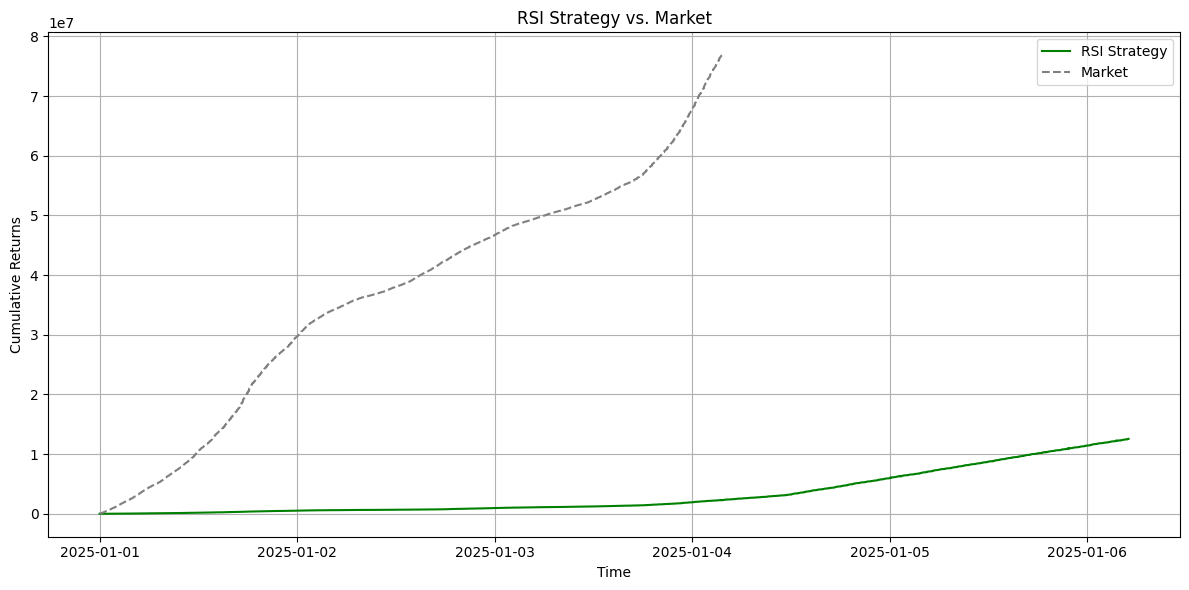

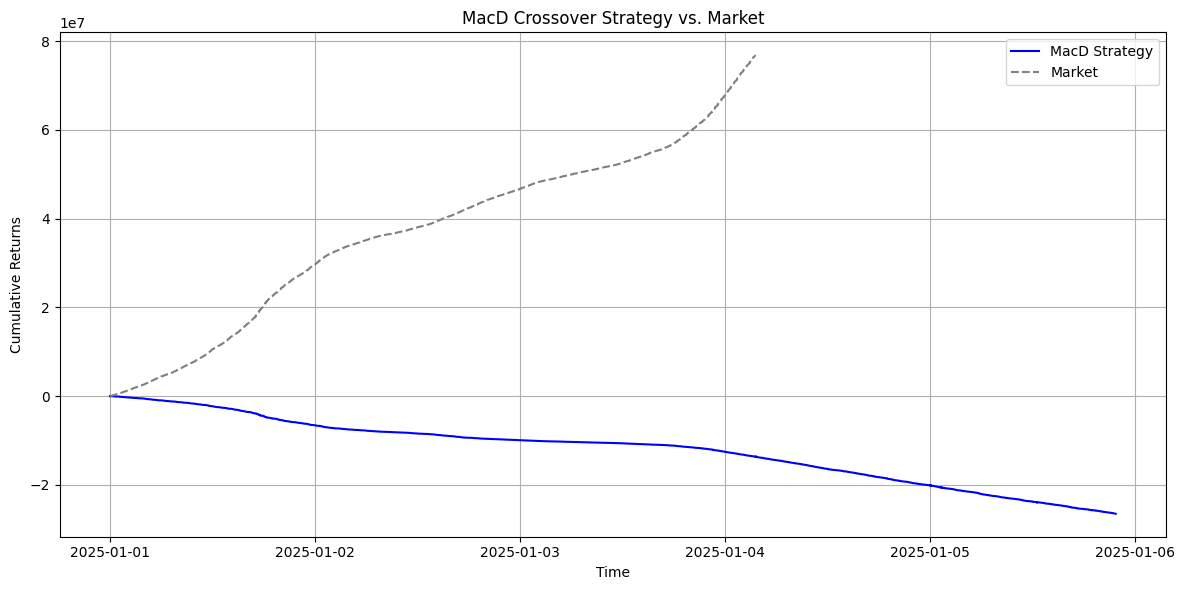

In [4]:
import numpy as np
import matplotlib.pyplot as plt


df = df.reset_index(drop=True)
df["timestamp"] = pd.date_range(start="2025-01-01", periods=len(df), freq="s")  # every second


# Define signals
df["signal"] = 0
df.loc[df["RSI"] < 30, "signal"] = 1   # Buy
df.loc[df["RSI"] > 70, "signal"] = -1  # Sell

# Simulate returns based on mid_price
df["returns"] = df["mid_price"].pct_change().fillna(0)
df["strategy_returns"] = df["signal"].shift(1) * df["returns"]

# Plot cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(df["timestamp"], df["strategy_returns"].cumsum(), label="RSI Strategy", color="green")
plt.plot(df["timestamp"], df["returns"].cumsum(), label="Market", color="gray", linestyle="--")
plt.title("RSI Strategy vs. Market")
plt.xlabel("Time")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Buy signal: MacD crosses above Signal
# Sell signal: MacD crosses below Signal
df["macd_signal"] = 0
df.loc[(df["MacD"] > df["Signal"]) & (df["MacD"].shift(1) <= df["Signal"].shift(1)), "macd_signal"] = 1
df.loc[(df["MacD"] < df["Signal"]) & (df["MacD"].shift(1) >= df["Signal"].shift(1)), "macd_signal"] = -1

df["macd_returns"] = df["macd_signal"].shift(1) * df["returns"]

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df["timestamp"], df["macd_returns"].cumsum(), label="MacD Strategy", color="blue")
plt.plot(df["timestamp"], df["returns"].cumsum(), label="Market", color="gray", linestyle="--")
plt.title("MacD Crossover Strategy vs. Market")
plt.xlabel("Time")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

